In [1]:
import os
import time
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from collections import deque
from tensorflow.keras import layers, Model

# Suprimir logs informativos de TF (opcional)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'




El paper usa una **Wide ResNet-28** ya que esta ofrece un buen balance, es lo sufientemente profunda para aprender las características del CIFAR-10, pero no tan grande como para ser imposible de entrenar con pocos datos etiquetados.
La configuramos con factor de anchura k=2 (~1.5M parámetros) como modelo base que es suficientemente manejable.

Mediante el bloque residual preactivado modificamos el orden clásico (Conv → BN → ReLU) a (BN → ReLU → Conv) lo cual mejora el flujo del gradiente.

In [2]:
class WideResBlock(layers.Layer):
    """
    Bloque residual pre-activado (BN → ReLU → Conv × 2).
    """

    def __init__(self, filters, stride=1, activate_before_residual=False, **kwargs):
        super().__init__(**kwargs)
        self.activate_before_residual = activate_before_residual
        self._stride  = stride
        self._filters = filters

        self.bn1   = layers.BatchNormalization(momentum=0.99)
        self.relu1 = layers.Activation('relu')
        self.conv1 = layers.Conv2D(
            filters, 3, strides=stride, padding='same',
            use_bias=False, kernel_initializer='he_normal'
        )
        self.bn2   = layers.BatchNormalization(momentum=0.99)
        self.relu2 = layers.Activation('relu')
        self.conv2 = layers.Conv2D(
            filters, 3, strides=1, padding='same',
            use_bias=False, kernel_initializer='he_normal'
        )
        self.shortcut = None

    def build(self, input_shape):
        in_ch = input_shape[-1]
        if self._stride != 1 or in_ch != self._filters:
            self.shortcut = layers.Conv2D(
                self._filters, 1, strides=self._stride, padding='same',
                use_bias=False, kernel_initializer='he_normal'
            )
        super().build(input_shape)

    def call(self, x, training=False):
        if self.activate_before_residual:
            x        = self.bn1(x, training=training)
            x        = self.relu1(x)
            residual = x
        else:
            residual = x
            x        = self.bn1(x, training=training)
            x        = self.relu1(x)

        x = self.conv1(x)
        x = self.bn2(x, training=training)
        x = self.relu2(x)
        x = self.conv2(x)

        if self.shortcut is not None:
            residual = self.shortcut(residual)

        return x + residual




def build_wide_resnet(num_classes=10, depth=28, widen_factor=2,
                      input_shape=(32, 32, 3)):
    """
    Construye el Wide ResNet del paper de MixMatch.

    """
    assert (depth - 4) % 6 == 0
    n        = (depth - 4) // 6
    channels = [16,
                16 * widen_factor,  
                32 * widen_factor,   
                64 * widen_factor]   

    inputs = tf.keras.Input(shape=input_shape)

    # Convolución inicial
    x = layers.Conv2D(channels[0], 3, padding='same',
                      use_bias=False, kernel_initializer='he_normal')(inputs)

    x = WideResBlock(channels[1], stride=1, activate_before_residual=True)(x)
    for _ in range(n - 1):
        x = WideResBlock(channels[1], stride=1)(x)

    x = WideResBlock(channels[2], stride=2)(x)
    for _ in range(n - 1):
        x = WideResBlock(channels[2], stride=1)(x)

    x = WideResBlock(channels[3], stride=2)(x)
    for _ in range(n - 1):
        x = WideResBlock(channels[3], stride=1)(x)

    # Cabeza clasificadora
    x = layers.BatchNormalization(momentum=0.99)(x)
    x = layers.Activation('relu')(x)
    x = layers.GlobalAveragePooling2D()(x)
    outputs = layers.Dense(num_classes, activation='softmax',
                           kernel_initializer='he_normal')(x)

    return Model(inputs, outputs, name=f'WideResNet-{depth}-{widen_factor}')


def build_model_paper(num_classes=10, large=False):
    """large=False → k=2 (~1.5M) | large=True → k=10 (~26M)"""
    return build_wide_resnet(num_classes=num_classes, depth=28,
                             widen_factor=10 if large else 2)


# Verificación rápida
model = build_model_paper(num_classes=10, large=False)
dummy = tf.zeros((4, 32, 32, 3))
out   = model(dummy, training=False)

print(f'Modelo     : {model.name}')
print(f'Output     : {out.shape}  (esperado: (4, 10))')
print(f'Parámetros : {model.count_params():,}  (esperado: ~1.47M)')

I0000 00:00:1789917212.289855      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789917212.292811      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Modelo     : WideResNet-28-2
Output     : (4, 10)  (esperado: (4, 10))
Parámetros : 1,471,226  (esperado: ~1.47M)



El paper usa un split estratificado: los `n_labeled` ejemplos se distribuyen uniformemente entre las 10 clases. El resto del training set actúa como datos **no etiquetados**.

Los experimentos del paper evalúan: **250, 500, 1000, 2000, 4000** etiquetas.

CIFAR-10 tiene distribuciones particulares de píxeles por canal (media ≠ 0.5, 
std ≠ 0.5). Normalizar con esa estadística específica coloca los valores en 
media 0 y varianza 1, lo cual estabiliza enormemente el entrenamiento del modelo 
y acelera la convergencia del optimizador Adam. En MixMatch esto es crítico: 
cuando aplicas MixUp interpolas píxeles entre dos imágenes (x' = λ·x₁ + (1-λ)·x₂). 
Si ambas no estuvieran normalizadas a la misma escala, la interpolación sería 
numéricamente inconsistente. El paper asume este preprocessing estándar (sección 4.1) 
porque facilita que gradientes fluyan uniformemente en todas las capas, mejorando 
la estabilidad especialmente crítica en SSL donde los datos no etiquetados tienen 
riesgo de causar inestabilidad si el modelo no está bien condicionado.

In [3]:
CIFAR10_MEAN = np.array([0.4914, 0.4822, 0.4465], dtype=np.float32)
CIFAR10_STD  = np.array([0.2471, 0.2435, 0.2616], dtype=np.float32)
NUM_CLASSES  = 10


def load_cifar10_ssl(n_labeled=250, seed=42):
    """
    Carga CIFAR-10 y genera el split semi-supervisado.

    Protocolo estándar del paper:
      - n_labeled ejemplos distribuidos uniformemente entre clases
      - Resto del training set (50000 - n_labeled) → no etiquetados
      - Normalización por media y std de CIFAR-10

    Retorna
    -------
    labeled_images, labeled_labels, unlabeled_images, test_images, test_labels
    """
    rng = np.random.RandomState(seed)

    (x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

    y_train = y_train.flatten().astype(np.int32)
    y_test  = y_test.flatten().astype(np.int32)
    x_train = (x_train.astype(np.float32) / 255.0 - CIFAR10_MEAN) / CIFAR10_STD
    x_test  = (x_test.astype(np.float32)  / 255.0 - CIFAR10_MEAN) / CIFAR10_STD

    # Selección estratificada: n_labeled / NUM_CLASSES por clase
    n_per_class = n_labeled // NUM_CLASSES
    assert n_per_class * NUM_CLASSES == n_labeled, \
        f'n_labeled debe ser múltiplo de {NUM_CLASSES}'

    labeled_idx, unlabeled_idx = [], []
    for c in range(NUM_CLASSES):
        idx_c = np.where(y_train == c)[0]
        rng.shuffle(idx_c)
        labeled_idx.extend(idx_c[:n_per_class].tolist())
        unlabeled_idx.extend(idx_c[n_per_class:].tolist())

    labeled_idx   = np.array(labeled_idx)
    unlabeled_idx = np.array(unlabeled_idx)

    labeled_images   = x_train[labeled_idx]
    labeled_labels   = y_train[labeled_idx]
    unlabeled_images = x_train[unlabeled_idx]

    print(f'[CIFAR-10 SSL]  Etiquetados   : {len(labeled_images):,}  '
          f'({n_per_class} por clase)')
    print(f'               No etiquetados : {len(unlabeled_images):,}')
    print(f'               Test           : {len(x_test):,}')

    return labeled_images, labeled_labels, unlabeled_images, x_test, y_test


def make_labeled_dataset(images, labels, batch_size, shuffle=True):
    """Dataset infinito (imagen, label_onehot) para datos etiquetados."""
    labels_oh = tf.keras.utils.to_categorical(labels, NUM_CLASSES).astype(np.float32)
    ds = tf.data.Dataset.from_tensor_slices((images, labels_oh))
    if shuffle:
        ds = ds.shuffle(len(images), reshuffle_each_iteration=True)
    return ds.repeat().batch(batch_size, drop_remainder=True).prefetch(tf.data.AUTOTUNE)


def make_unlabeled_dataset(images, batch_size, shuffle=True):
    """Dataset infinito de imágenes para datos no etiquetados."""
    ds = tf.data.Dataset.from_tensor_slices(images)
    if shuffle:
        ds = ds.shuffle(len(images), reshuffle_each_iteration=True)
    return ds.repeat().batch(batch_size, drop_remainder=True).prefetch(tf.data.AUTOTUNE)


def make_test_dataset(images, labels, batch_size=256):
    """Dataset de evaluación (sin shuffle, sin repeat)."""
    labels_oh = tf.keras.utils.to_categorical(labels, NUM_CLASSES).astype(np.float32)
    ds = tf.data.Dataset.from_tensor_slices((images, labels_oh))
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)


N_LABELED = 250 
SEED      = 0

labeled_imgs, labeled_lbls, unlabeled_imgs, test_imgs, test_lbls = \
    load_cifar10_ssl(n_labeled=N_LABELED, seed=SEED)


unique, counts = np.unique(labeled_lbls, return_counts=True)
print(f'\nEjemplos por clase: {dict(zip(unique, counts))}')

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1599s 9us/step
[CIFAR-10 SSL]  Etiquetados   : 250  (25 por clase)
               No etiquetados : 49,750
               Test           : 10,000

Ejemplos por clase: {np.int32(0): np.int64(25), np.int32(1): np.int64(25), np.int32(2): np.int64(25), np.int32(3): np.int64(25), np.int32(4): np.int64(25), np.int32(5): np.int64(25), np.int32(6): np.int64(25), np.int32(7): np.int64(25), np.int32(8): np.int64(25), np.int32(9): np.int64(25)}




El paper MixMatch unifica tres paradigmas SSL en un solo algoritmo: primero,
la augmentación genera variantes de datos para consistency regularization
(el modelo debe predecir igual ante perturbaciones). Segundo, el sharpening
con temperatura T reduce la entropía de las predicciones sobre datos no
etiquetados, implementando entropy minimization (el modelo debe ser confiado).
Tercero, MixUp modificado (con λ'≥0.5) mezcla labeled y unlabeled juntos,
actuando como regularización tradicional que fuerza comportamiento convexo entre
ejemplos. La pérdida final combina todo: cross-entropy en datos etiquetados
(superviso directo) más MSE en no etiquetados (pseudo-label suave). Este híbrido
permite al modelo aprender de las 49,750 imágenes no etiquetadas de CIFAR-10
usando solo 250 etiquetas, porque el conocimiento de esas pocas etiquetas ayuda
a través de la red por consistency + entropy minimization, propagándose a todo
el dataset vía MixUp.


In [4]:

def augment_cifar(images, pad=4):
    h, w, c = 32, 32, 3
    images = tf.pad(images, [[0,0],[pad,pad],[pad,pad],[0,0]], mode='REFLECT')
    
    images = tf.map_fn(lambda im: tf.image.random_crop(im, size=[h, w, c]), images)
    return tf.image.random_flip_left_right(images)


def sharpen(p, T):
    """
    Paper usa T = 0.5 en todos los experimentos.
    """
    p_sharp = tf.pow(p, 1.0 / T)
    return p_sharp / tf.reduce_sum(p_sharp, axis=1, keepdims=True)


def guess_labels(model, unlabeled_batch, K, T):
    """
    Genera etiquetas artificiales para datos no etiquetados.

    Proceso:
      1. Crear K aumentaciones de cada imagen
      2. Predicción del modelo para cada aumentación
      3. Promedio → q̄_b 
      4. Sharpening → q_b

    Retorna: (guessed_labels, lista_de_K_aumentaciones)
    """
    aug_unlabeled, predictions = [], []

    for _ in range(K):
        aug_u = augment_cifar(unlabeled_batch)
        aug_unlabeled.append(aug_u)
        predictions.append(model(aug_u, training=True))

    avg_preds = tf.reduce_mean(tf.stack(predictions, axis=0), axis=0)

    return sharpen(avg_preds, T), aug_unlabeled
    
def mixup(x1, p1, x2, p2, alpha):
    """
    MixUp modificado del paper 
    """
    batch_size = tf.shape(x1)[0]
    
    gamma1 = tf.random.gamma([batch_size], alpha)
    gamma2 = tf.random.gamma([batch_size], alpha)
    lam = gamma1 / (gamma1 + gamma2)
    lam = tf.cast(lam, tf.float32)
    
    lam_prime = tf.maximum(lam, 1.0 - lam)

    lam_img   = tf.reshape(lam_prime, [-1, 1, 1, 1])
    lam_label = tf.reshape(lam_prime, [-1, 1])
    
    return (lam_img   * x1 + (1.0 - lam_img)   * x2,
            lam_label * p1 + (1.0 - lam_label)  * p2)


# Algoritmo mixmath completo

def mixmatch(model, labeled_batch, labels_onehot, unlabeled_batch,
             T=0.5, K=2, alpha=0.75):
    # Augmentar datos etiquetados
    B = tf.shape(labeled_batch)[0]

    X_hat = (augment_cifar(labeled_batch), labels_onehot)
    
    # Adivinar etiquetas para datos no etiquetados
    guessed_labels, aug_unlabeled_list = guess_labels(model, unlabeled_batch, K, T)
    guessed_labels = tf.stop_gradient(guessed_labels)  # estándar en SSL

    # Construir Û (datos no etiquetados + pseudo-labels)
    U_hat_images = tf.concat(aug_unlabeled_list, axis=0)   # (K*B, H, W, C)
    U_hat_labels = tf.tile(guessed_labels, [K, 1])          # (K*B, num_classes)

    # Crear W = shuffle(X̂ ∪ Û)
    W_images = tf.concat([X_hat[0], U_hat_images], axis=0)
    W_labels = tf.concat([X_hat[1], U_hat_labels], axis=0)
    idx      = tf.random.shuffle(tf.range(tf.shape(W_images)[0]))
    W_images = tf.gather(W_images, idx)
    W_labels = tf.gather(W_labels, idx)

    # MixUp sobre datos etiquetados
    X_mix_images, X_mix_labels = mixup(
        X_hat[0], X_hat[1], W_images[:B], W_labels[:B], alpha
    )

    # MixUp sobre datos no etiquetados
    KB = tf.shape(U_hat_images)[0]
    U_mix_images, U_mix_labels = mixup(
        U_hat_images, U_hat_labels,
        W_images[B:B+KB], W_labels[B:B+KB], alpha
    )

    return ({'images': X_mix_images, 'labels': X_mix_labels},
            {'images': U_mix_images, 'labels': U_mix_labels})

def mixmatch_loss(model, X_prime, U_prime, lambda_u, training=True):
    """
    L = L_X + λ_U · L_U   (Ec. 5)

      L_X = (1/|X'|) Σ H(p, p_model)              (Ec. 3, cross-entropy)
      L_U = (1/(L·|U'|)) Σ ||q - p_model||²       (Ec. 4, Brier / L2 con 1/L)

    Nota: se hace UN solo forward pass sobre [X' ; U'] concatenados para que
    BatchNorm calcule sus estadísticas sobre el batch completo, igual que en la
    implementación oficial (evita estadísticas inconsistentes entre las dos
    ramas y estabiliza el entrenamiento).
    """
    B = tf.shape(X_prime['images'])[0]

    all_images = tf.concat([X_prime['images'], U_prime['images']], axis=0)
    all_probs  = model(all_images, training=training)
    probs_x = all_probs[:B]
    probs_u = all_probs[B:]

    loss_x = tf.reduce_mean(
        tf.keras.losses.categorical_crossentropy(X_prime['labels'], probs_x)
    )

    loss_u = tf.reduce_mean(tf.square(U_prime['labels'] - probs_u))

    return loss_x + lambda_u * loss_u, loss_x, loss_u




El entrenamiento de MixMatch requiere tres mecanismos de estabilización:

- EMA mantiene una copia suavizada de los pesos (decay=0.999) para evaluar modelos más estables sin ruido de
optimización instantánea.

- LambdaUScheduler aplica una rampa lineal a λ_U en las primeras 16,000 iteraciones porque las pseudo-etiquetas iniciales son poco confiables; aumentar gradualmente su peso evita que el modelo diverga.

- MedianCheckpointTracker reporta la mediana de los últimos 3 checkpoints en lugar del mejor, evitando sobreafinamiento en validación.

- Finalmente, train_step() ejecuta el loop atómico: MixMatch() → loss() → gradientes → weight decay manual.

Juntas, estas herramientas convierten el algoritmo MixMatch teórico en un pipeline de entrenamiento robusto y reproducible.

In [5]:
class ExponentialMovingAverage:
    """
    Mantiene una copia suavizada de los pesos del modelo.

    El paper usa decay=0.999 y evalúa siempre con el modelo EMA
    """

    def __init__(self, model, decay=0.999):
        self.decay          = decay
        self.shadow_weights = [w.numpy().copy() for w in model.weights]

    def update(self, model):
        for shadow, current in zip(self.shadow_weights, model.weights):
            shadow -= (1.0 - self.decay) * (shadow - current.numpy())

    def apply_to(self, model):
        """Copia pesos sombra → model (para evaluación)."""
        for shadow, var in zip(self.shadow_weights, model.weights):
            var.assign(shadow)

class LambdaUScheduler:
    """
    Estabiliza el entrenamiento inicial cuando las etiquetas
    adivinadas son todavía poco fiables.
    """

    def __init__(self, lambda_u_max, warmup_steps=16000):
        self.lambda_u_max = lambda_u_max
        self.warmup_steps = warmup_steps

    def __call__(self, step):
        if step >= self.warmup_steps:
            return self.lambda_u_max
        return (float(step) / self.warmup_steps) * self.lambda_u_max

class MedianCheckpointTracker:
    """
    Evita el overfitting sobre validación al elegir el mejor checkpoint
    y produce estimaciones más robustas del rendimiento.
    """

    def __init__(self, window=20):
        self.error_rates = deque(maxlen=window)

    def update(self, error_rate):
        self.error_rates.append(error_rate)

    def median_error(self):
        return float(np.median(list(self.error_rates))) if self.error_rates else None

    def __len__(self):
        return len(self.error_rates)


def compute_accuracy(model, dataset):
    """Accuracy y error rate sobre un tf.data.Dataset de (imagen, label_onehot)."""
    correct, total = 0, 0
    for images, labels_oh in dataset:
        preds  = model(images, training=False)
        correct += tf.reduce_sum(
            tf.cast(tf.equal(tf.argmax(preds, 1), tf.argmax(labels_oh, 1)), tf.int32)
        ).numpy()
        total += images.shape[0]
    acc = correct / total
    return acc, 1.0 - acc


def evaluate_with_ema(model, ema, test_ds):
    """
    Evalúa con pesos EMA sin alterar los pesos de entrenamiento.
    Guarda → aplica EMA → evalúa → restaura.
    """
    saved = [v.numpy().copy() for v in model.weights]
    ema.apply_to(model)
    acc, err = compute_accuracy(model, test_ds)
    for var, w in zip(model.weights, saved):
        var.assign(w)
    return acc, err


@tf.function
def train_step(model, optimizer, labeled_images, labels_onehot,
               unlabeled_images, lambda_u_val, T, K, alpha, wd):
    """
    Un paso completo:
      1. MixMatch → X', U'
      2. Pérdida total
      3. Gradientes y actualización de pesos
      4. Weight decay manual (L2 sobre parámetros)
    """
    X_prime, U_prime = mixmatch(
        model, labeled_images, labels_onehot, unlabeled_images,
        T=T, K=K, alpha=alpha
    )

    with tf.GradientTape() as tape:
        loss_total, loss_x, loss_u = mixmatch_loss(
            model, X_prime, U_prime, lambda_u=lambda_u_val, training=True
        )

    grads = tape.gradient(loss_total, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))

    for var in model.trainable_variables:
        if 'kernel' in var.name:
            var.assign(var * (1.0 - wd))

    return loss_total, loss_x, loss_u


---
# Visualizaciones 

Se utiliza el sharpening como mecanismo de reducción de entropía, reduce la confianza en distribuciones suaves para generar
pseudo-etiquetas más definidas. Este código visualiza cómo la temperatura T controla este efecto, cuando T→0 la distribución converge a one-hot (máxima
confianza), cuando T=1 no hay cambio (distribución original). 

El paper elige T=0.5 como balance: las etiquetas adivinadas quedan lo suficientemente sharpen para ser útiles, pero no tanto que introduzcan ruido si el modelo se equivoca.

La entropía H disminuye monotónicamente con T más bajo, cuantificando cómo el sharpening fuerza decisiones más binarias. Visualizar este efecto con barras coloreadas (rojo para la clase dominante) ayuda a entender por qué entropy minimization es crucial en SSL: sin ella, el modelo asignaría probabilidades uniformes a datos no etiquetados y aprendería muy lentamente.


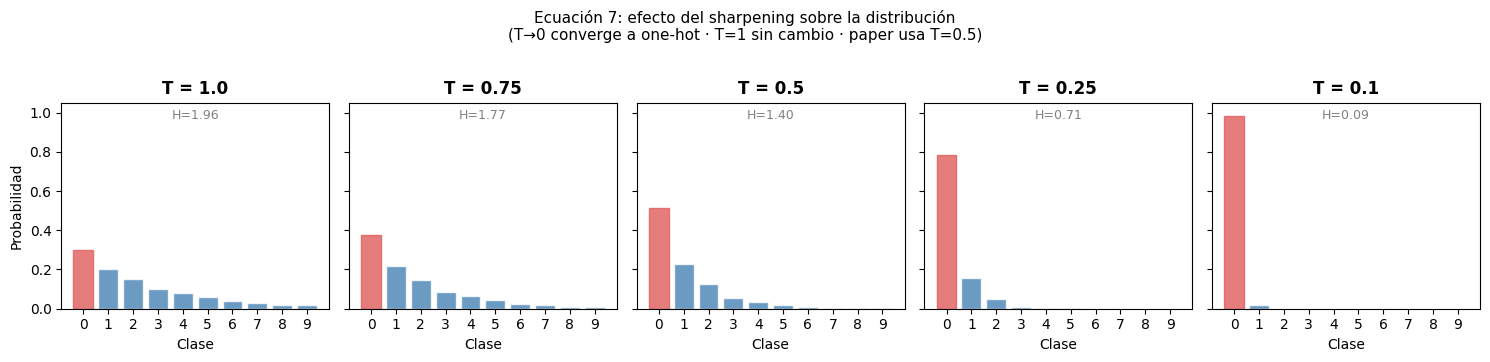

In [6]:
p_soft = tf.constant([[0.30, 0.20, 0.15, 0.10, 0.08,
                        0.06, 0.04, 0.03, 0.02, 0.02]])
temps  = [1.0, 0.75, 0.5, 0.25, 0.1]

fig, axes = plt.subplots(1, len(temps), figsize=(15, 3.5), sharey=True)
for ax, T_val in zip(axes, temps):
    s = sharpen(p_soft, T_val).numpy()[0]
    bars = ax.bar(range(10), s, color='steelblue', alpha=0.8, edgecolor='white')
    bars[0].set_color('#e05c5c')  # marca la clase con mayor prob
    ax.set_title(f'T = {T_val}', fontsize=12, fontweight='bold')
    ax.set_xticks(range(10))
    ax.set_xlabel('Clase')
    ax.set_ylim(0, 1.05)
    if T_val == 1.0:
        ax.set_ylabel('Probabilidad')
    entropy = -np.sum(s * np.log(s + 1e-9))
    ax.text(0.5, 0.92, f'H={entropy:.2f}', transform=ax.transAxes,
            ha='center', fontsize=9, color='gray')

plt.suptitle('Ecuación 7: efecto del sharpening sobre la distribución\n'
             '(T→0 converge a one-hot · T=1 sin cambio · paper usa T=0.5)',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

# Efecto del MixUp modificado
Este es el pilar de regularización tradicional en MixMatch. A diferencia del MixUp original, la modificación λ' = max(λ, 1-λ) garantiza que la interpolación siempre tenga λ' ≥ 0.5, manteniendo x' más cercano a x₁ que a x₂.

Esto es crítico en el algoritmo ya que cuando se mezclan labeled y unlabeled después del shuffle, esta restricción preserva el "orden" dentro del batch mixto para que L_X y L_U se calculen correctamente en la función de pérdida. Visualmente, con dos imágenes reales de CIFAR-10, se aprecia cómo λ=0.9 produce una imagen casi idéntica a la primera, mientras que λ=0.5 es un balance, pero nunca una copia más cercana a la segunda.

Este comportamiento es lo que permite a MixMatch combinar los tres paradigmas SSL sin conflicto: los datos etiquetados no se pierden en la interpolación porque siempre dominan en la mezcla.

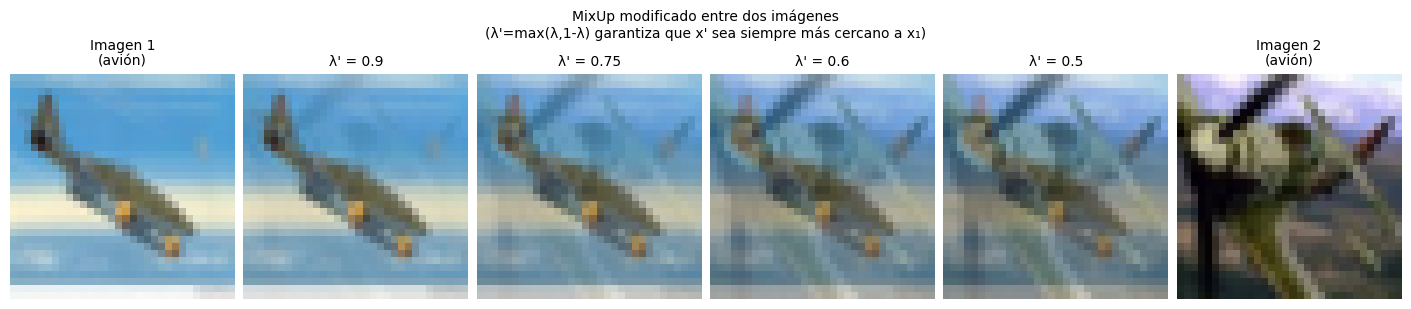

In [7]:

def denorm(img):
    """Revierte la normalización para visualizar."""
    return np.clip(img * CIFAR10_STD + CIFAR10_MEAN, 0, 1)

CIFAR10_CLASSES = ['avión','auto','pájaro','gato','ciervo',
                   'perro','rana','caballo','barco','camión']

img1 = labeled_imgs[0:1]
img2 = labeled_imgs[1:2]
cls1 = CIFAR10_CLASSES[labeled_lbls[0]]
cls2 = CIFAR10_CLASSES[labeled_lbls[1]]

lam_vals = [0.9, 0.75, 0.6, 0.5] 

fig, axes = plt.subplots(1, len(lam_vals) + 2,
                         figsize=(14, 3), constrained_layout=True)

axes[0].imshow(denorm(img1[0]))
axes[0].set_title(f'Imagen 1\n({cls1})', fontsize=10)
axes[0].axis('off')

for i, lam in enumerate(lam_vals):
    lam_t  = tf.constant([[lam, lam, lam]], dtype=tf.float32)
    lam_t  = tf.reshape(tf.constant([lam], dtype=tf.float32), [1, 1, 1, 1])
    mixed  = (lam_t * img1 + (1.0 - lam_t) * img2)
    axes[i+1].imshow(denorm(mixed[0]))
    axes[i+1].set_title(f"λ' = {lam}", fontsize=10)
    axes[i+1].axis('off')

axes[-1].imshow(denorm(img2[0]))
axes[-1].set_title(f'Imagen 2\n({cls2})', fontsize=10)
axes[-1].axis('off')

fig.suptitle('MixUp modificado entre dos imágenes\n'
             '(λ\'=max(λ,1-λ) garantiza que x\' sea siempre más cercano a x₁)',
             fontsize=10)
plt.show()

---
# Experimento 1

Con las componentes del algoritmo verificadas visualmente, pasamos al entrenamiento. Se realizan dos experimentos con distinto presupuesto de etiquetas para poder comparar el comportamiento del modelo bajo condiciones de escasez extrema (250 etiquetas) y condiciones más holgadas (4000 etiquetas). Ambos usan la misma arquitectura, los mismos hiperparámetros y el mismo número de datos no etiquetados, de forma que la única variable es la cantidad de supervisión disponible.

Para reproducir el paper empleamos `EPOCHS=20, STEPS_PER_EPOCH=1024` en vez de los `EPOCHS=1024, STEPS_PER_EPOCH=1024` por límites de computación.


In [8]:
# Hiperparámetros

BATCH_SIZE = 64

LEARNING_RATE = 0.002
WEIGHT_DECAY  = 0.02 * LEARNING_RATE

LAMBDA_U_MAX    = 75.0   
T_SHARPEN       = 0.5    
K_AUGMENTATIONS = 2     
ALPHA_MIXUP     = 0.75   
EMA_DECAY       = 0.999
WARMUP_STEPS    = 4096  

EPOCHS          = 20
STEPS_PER_EPOCH = 1024   
CHECKPOINT_EVERY = 2      
LOG_EVERY_STEPS  = 50  

In [9]:
tf.random.set_seed(SEED)
np.random.seed(SEED)

model     = build_model_paper(num_classes=NUM_CLASSES, large=False)
optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)
ema       = ExponentialMovingAverage(model, decay=EMA_DECAY)

lambda_scheduler    = LambdaUScheduler(LAMBDA_U_MAX, warmup_steps=WARMUP_STEPS)
checkpoint_tracker  = MedianCheckpointTracker(window=3)

labeled_ds   = make_labeled_dataset(labeled_imgs, labeled_lbls, BATCH_SIZE)
unlabeled_ds = make_unlabeled_dataset(unlabeled_imgs, BATCH_SIZE)
test_ds      = make_test_dataset(test_imgs, test_lbls)

labeled_iter   = iter(labeled_ds)
unlabeled_iter = iter(unlabeled_ds)

history = {'train_loss': [], 'test_error': [], 'loss_x': [], 'loss_u': []}

print(f'Modelo: {model.name} — {model.count_params():,} parámetros')

Modelo: WideResNet-28-2 — 1,471,226 parámetros


In [10]:


global_step = 0

for epoch in range(1, EPOCHS + 1):
    epoch_losses, epoch_lx, epoch_lu = [], [], []
    t0 = time.time()

    for step in range(STEPS_PER_EPOCH):
        # Batches del siguiente paso
        labeled_batch, labels_oh = next(labeled_iter)
        unlabeled_batch          = next(unlabeled_iter)

        lambda_u_val = tf.constant(lambda_scheduler(global_step), dtype=tf.float32)

        # Paso de entrenamiento
        loss_t, loss_x, loss_u = train_step(
            model, optimizer,
            labeled_batch, labels_oh, unlabeled_batch,
            lambda_u_val,
            T=tf.constant(T_SHARPEN,    dtype=tf.float32),
            K=K_AUGMENTATIONS,
            alpha=ALPHA_MIXUP,
            wd=tf.constant(WEIGHT_DECAY, dtype=tf.float32)
        )

        ema.update(model)
        epoch_losses.append(float(loss_t))
        epoch_lx.append(float(loss_x))
        epoch_lu.append(float(loss_u))
        global_step += 1

        if global_step % LOG_EVERY_STEPS == 0:
            print(f'  step {global_step:5d} | '
                  f'L={float(loss_t):.3f}  '
                  f'Lx={float(loss_x):.3f}  '
                  f'Lu={float(loss_u):.4f}  '
                  f'λ_U={float(lambda_u_val):.1f}')

    # Evaluación con EMA al final de cada época
    acc, err = evaluate_with_ema(model, ema, test_ds)
    elapsed  = time.time() - t0

    history['train_loss'].append(np.mean(epoch_losses))
    history['test_error'].append(err)
    history['loss_x'].append(np.mean(epoch_lx))
    history['loss_u'].append(np.mean(epoch_lu))

    print(f'\n► Época {epoch:3d}/{EPOCHS}  '
          f'Loss={np.mean(epoch_losses):.4f}  '
          f'Test error={err*100:.2f}%  '
          f'Acc={acc*100:.2f}%  '
          f'({elapsed:.1f}s)')

    # Checkpoint + mediana
    if epoch % CHECKPOINT_EVERY == 0:
        checkpoint_tracker.update(err)
        if checkpoint_tracker.median_error() is not None:
            print(f'  [ckpt] Mediana error '
                  f'(últimos {len(checkpoint_tracker)}): '
                  f'{checkpoint_tracker.median_error()*100:.2f}%')

  step    50 | L=1.546  Lx=1.539  Lu=0.0081  λ_U=0.9
  step   100 | L=1.460  Lx=1.441  Lu=0.0109  λ_U=1.8
  step   150 | L=1.336  Lx=1.307  Lu=0.0104  λ_U=2.7
  step   200 | L=1.040  Lx=1.001  Lu=0.0109  λ_U=3.6
  step   250 | L=1.272  Lx=1.214  Lu=0.0127  λ_U=4.6
  step   300 | L=1.152  Lx=1.094  Lu=0.0106  λ_U=5.5
  step   350 | L=1.331  Lx=1.259  Lu=0.0113  λ_U=6.4
  step   400 | L=1.074  Lx=0.985  Lu=0.0122  λ_U=7.3
  step   450 | L=1.085  Lx=1.006  Lu=0.0095  λ_U=8.2
  step   500 | L=1.131  Lx=1.010  Lu=0.0133  λ_U=9.1
  step   550 | L=1.153  Lx=1.056  Lu=0.0096  λ_U=10.1
  step   600 | L=1.049  Lx=0.930  Lu=0.0108  λ_U=11.0
  step   650 | L=1.102  Lx=0.989  Lu=0.0095  λ_U=11.9
  step   700 | L=1.072  Lx=0.943  Lu=0.0101  λ_U=12.8
  step   750 | L=0.977  Lx=0.833  Lu=0.0105  λ_U=13.7
  step   800 | L=0.970  Lx=0.835  Lu=0.0092  λ_U=14.6
  step   850 | L=1.029  Lx=0.889  Lu=0.0090  λ_U=15.5
  step   900 | L=0.988  Lx=0.827  Lu=0.0098  λ_U=16.5
  step   950 | L=0.963  Lx=0.808  Lu=0

El experimento 1 entrena con 250 etiquetas durante 20 épocas (20.480 steps), frente a las 1024 épocas del paper (1.048.576 steps). El test error baja de forma sostenida del 62.0% en la época 1 al 31.3% en la época 20, con una meseta en torno al 38% entre las épocas 5 y 8 y una caída más marcada a partir de la 14. La curva sigue descendiendo al terminar, así que el resultado está limitado por el presupuesto de steps y no por una convergencia real. El loss total sube hasta la época 5 no por divergencia, sino porque λ_U completa su rampa en el step 4096 (época 4) y el término λ_U · L_U se suma a L_X; a partir de ahí baja de forma suave. L_X pasa de 1.1 a 0.8 y L_U se mantiene en torno a 0.01.

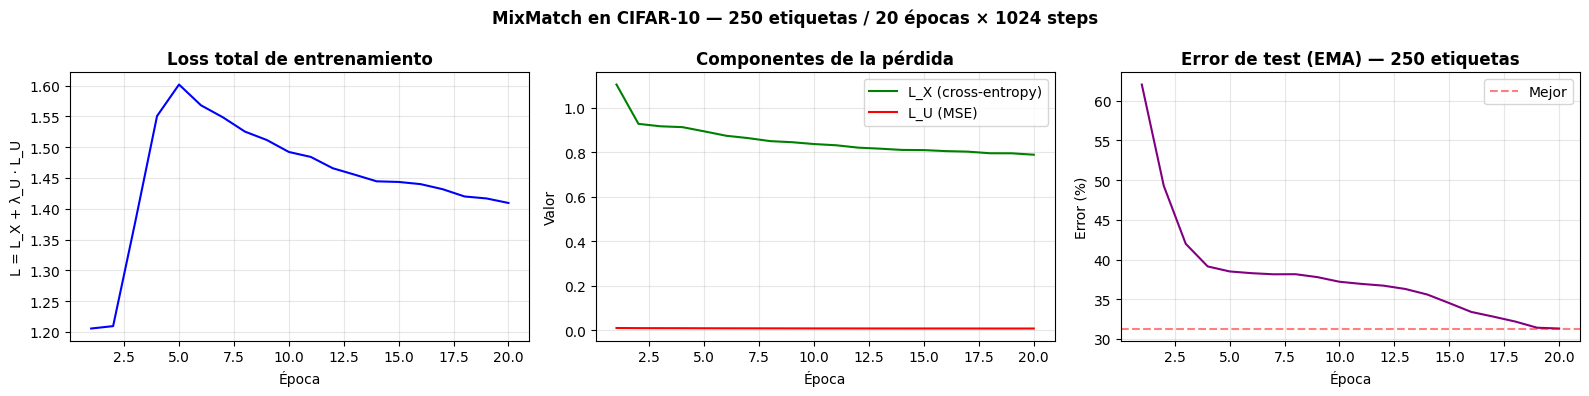

  Etiquetas usadas  : 250
  Épocas            : 20 × 1024 steps
  Mejor error test  : 31.31%
  Último error test : 31.31%
  Mediana (últimos 3 ckpts): 32.19%

  Referencia del paper (CIFAR-10):
  Error reportado   : 11.08% (con 1024 épocas completas)


In [11]:
epochs_range = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(epochs_range, history['train_loss'], 'b-', linewidth=1.5)
axes[0].set_title('Loss total de entrenamiento', fontweight='bold')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('L = L_X + λ_U · L_U')
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history['loss_x'], 'g-', label='L_X (cross-entropy)', linewidth=1.5)
axes[1].plot(epochs_range, history['loss_u'], 'r-', label='L_U (MSE)', linewidth=1.5)
axes[1].set_title('Componentes de la pérdida', fontweight='bold')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Valor')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(epochs_range, [e*100 for e in history['test_error']],
             'purple', linewidth=1.5)
axes[2].set_title(f'Error de test (EMA) — {N_LABELED} etiquetas', fontweight='bold')
axes[2].set_xlabel('Época')
axes[2].set_ylabel('Error (%)')
axes[2].grid(True, alpha=0.3)
axes[2].axhline(y=min(e*100 for e in history['test_error']),
                color='red', linestyle='--', alpha=0.5, label='Mejor')
axes[2].legend()

plt.suptitle(f'MixMatch en CIFAR-10 — {N_LABELED} etiquetas / '
             f'{EPOCHS} épocas × {STEPS_PER_EPOCH} steps',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Resumen final ─────────────────────────────────────────────────────
best_err = min(history['test_error'])
last_err = history['test_error'][-1]

print('=' * 55)
print(f'  Etiquetas usadas  : {N_LABELED}')
print(f'  Épocas            : {EPOCHS} × {STEPS_PER_EPOCH} steps')
print(f'  Mejor error test  : {best_err*100:.2f}%')
print(f'  Último error test : {last_err*100:.2f}%')
if checkpoint_tracker.median_error() is not None:
    print(f'  Mediana (últimos {len(checkpoint_tracker)} ckpts): '
          f'{checkpoint_tracker.median_error()*100:.2f}%')
print()
print('  Referencia del paper (CIFAR-10):')
paper_results = {250: 11.08, 500: 9.65, 1000: 7.75, 2000: 7.03, 4000: 6.24}
if N_LABELED in paper_results:
    print(f'  Error reportado   : {paper_results[N_LABELED]:.2f}% '
          '(con 1024 épocas completas)')
print('=' * 55)

# Experimento 2

El experimento 2 entrena con 4000 etiquetas durante 20 épocas (20.480 steps), con los mismos hiperparámetros que el experimento 1. El test error baja del 67.3% en la época 1 al 11.13% en la época 20: la mayor parte de la mejora ocurre en las primeras 6 épocas (16.6% en la época 6) y después la curva se aplana, con menos de 0.5 puntos por época a partir de la época 12. No se observa inestabilidad una vez que λ_U alcanza su valor máximo. La mediana de checkpoints que imprime este experimento usa una ventana de 20 (todos los checkpoints, incluidos los de las primeras épocas), por lo que no es comparable con la del experimento 1; con una ventana de 3 sería del 11.52%, calculada a partir de los errores de las épocas 16, 18 y 20.

In [13]:
N_LABELED_2 = 4000
# Datos
labeled_imgs_2, labeled_lbls_2, unlabeled_imgs_2, _, _ = \
    load_cifar10_ssl(n_labeled=N_LABELED_2, seed=SEED)

labeled_ds_2   = make_labeled_dataset(labeled_imgs_2, labeled_lbls_2, BATCH_SIZE)
unlabeled_ds_2 = make_unlabeled_dataset(unlabeled_imgs_2, BATCH_SIZE)
labeled_iter_2   = iter(labeled_ds_2)
unlabeled_iter_2 = iter(unlabeled_ds_2)

tf.random.set_seed(SEED)
model_2    = build_model_paper(num_classes=NUM_CLASSES, large=False)
optimizer_2 = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)
optimizer_2.build(model_2.trainable_variables)
ema_2       = ExponentialMovingAverage(model_2, decay=EMA_DECAY)

lambda_scheduler_2   = LambdaUScheduler(LAMBDA_U_MAX, warmup_steps=WARMUP_STEPS)
checkpoint_tracker_2 = MedianCheckpointTracker(window=20)

history_2 = {'train_loss': [], 'test_error': [], 'loss_x': [], 'loss_u': []}
global_step_2 = 0

print(f'Experimento 2 — {N_LABELED_2} etiquetas')
print(f'Modelo: {model_2.name} — {model_2.count_params():,} parámetros')

for epoch in range(1, EPOCHS + 1):
    epoch_losses, epoch_lx, epoch_lu = [], [], []
    t0 = time.time()

    for step in range(STEPS_PER_EPOCH):
        labeled_batch, labels_oh = next(labeled_iter_2)
        unlabeled_batch          = next(unlabeled_iter_2)

        lambda_u_val = tf.constant(lambda_scheduler_2(global_step_2), dtype=tf.float32)

        loss_t, loss_x, loss_u = train_step(
            model_2, optimizer_2,
            labeled_batch, labels_oh, unlabeled_batch,
            lambda_u_val,
            T=tf.constant(T_SHARPEN,     dtype=tf.float32),
            K=K_AUGMENTATIONS,
            alpha=ALPHA_MIXUP,
            wd=tf.constant(WEIGHT_DECAY, dtype=tf.float32)
        )

        ema_2.update(model_2)
        epoch_losses.append(float(loss_t))
        epoch_lx.append(float(loss_x))
        epoch_lu.append(float(loss_u))
        global_step_2 += 1

        if global_step_2 % LOG_EVERY_STEPS == 0:
            print(f'  step {global_step_2:5d} | '
                  f'L={float(loss_t):.3f}  '
                  f'Lx={float(loss_x):.3f}  '
                  f'Lu={float(loss_u):.4f}  '
                  f'λ_U={float(lambda_u_val):.1f}')

    acc, err = evaluate_with_ema(model_2, ema_2, test_ds)
    elapsed  = time.time() - t0

    history_2['train_loss'].append(np.mean(epoch_losses))
    history_2['test_error'].append(err)
    history_2['loss_x'].append(np.mean(epoch_lx))
    history_2['loss_u'].append(np.mean(epoch_lu))

    print(f'\n► Época {epoch:3d}/{EPOCHS}  '
          f'Loss={np.mean(epoch_losses):.4f}  '
          f'Test error={err*100:.2f}%  '
          f'Acc={acc*100:.2f}%  '
          f'({elapsed:.1f}s)')

    if epoch % CHECKPOINT_EVERY == 0:
        checkpoint_tracker_2.update(err)
        if checkpoint_tracker_2.median_error() is not None:
            print(f'  [ckpt] Mediana error '
                  f'(últimos {len(checkpoint_tracker_2)}): '
                  f'{checkpoint_tracker_2.median_error()*100:.2f}%')

[CIFAR-10 SSL]  Etiquetados   : 4,000  (400 por clase)
               No etiquetados : 46,000
               Test           : 10,000
Experimento 2 — 4000 etiquetas
Modelo: WideResNet-28-2 — 1,471,226 parámetros
  step    50 | L=2.238  Lx=2.233  Lu=0.0056  λ_U=0.9
  step   100 | L=1.971  Lx=1.960  Lu=0.0058  λ_U=1.8
  step   150 | L=2.055  Lx=2.036  Lu=0.0072  λ_U=2.7
  step   200 | L=1.784  Lx=1.764  Lu=0.0057  λ_U=3.6
  step   250 | L=1.827  Lx=1.791  Lu=0.0079  λ_U=4.6
  step   300 | L=1.861  Lx=1.816  Lu=0.0082  λ_U=5.5
  step   350 | L=1.700  Lx=1.655  Lu=0.0071  λ_U=6.4
  step   400 | L=1.658  Lx=1.602  Lu=0.0077  λ_U=7.3
  step   450 | L=1.805  Lx=1.732  Lu=0.0089  λ_U=8.2
  step   500 | L=1.553  Lx=1.469  Lu=0.0092  λ_U=9.1
  step   550 | L=1.656  Lx=1.583  Lu=0.0072  λ_U=10.1
  step   600 | L=1.645  Lx=1.555  Lu=0.0082  λ_U=11.0
  step   650 | L=1.660  Lx=1.562  Lu=0.0083  λ_U=11.9
  step   700 | L=1.744  Lx=1.630  Lu=0.0089  λ_U=12.8
  step   750 | L=1.574  Lx=1.452  Lu=0.0089

# Conclusiones del experimento

Con aproximadamente el 2% de los steps del paper (20.480 frente a 1.048.576), la implementación alcanza un error de test del 11.13% con 4000 etiquetas (paper: 6.24%) y del 31.31% con 250 etiquetas (paper: 11.08%). La brecha con el paper es mucho mayor con 250 etiquetas, y su curva de error sigue bajando al terminar, por lo que es donde más se nota el presupuesto reducido de cómputo; con 4000 etiquetas la curva ya se aplana. No se ha comprobado con un entrenamiento más largo que el presupuesto explique toda la diferencia. La diferencia entre ambos experimentos (31% frente a 11%) muestra la sensibilidad de MixMatch a la cantidad de etiquetas disponibles, que es precisamente la propiedad central que el paper estudia. Los resultados corresponden a una única ejecución con semilla 0.